In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT => Temperature
# V => vacuum
# AP => pressure
# RH => humidity

# PE => Produced Energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis = 1)
y = df["PE"]

In [7]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [8]:
# split the data 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y , test_size = 0.2, random_state = 42
)

In [9]:
X_train.head()

,AT,V,AP,RH
5487,25.24,63.47,1011.30,66.21
3522,26.09,70.40,1007.41,85.37
6916,26.63,73.68,1015.15,85.13
7544,32.06,71.85,1007.90,56.44
7600,28.70,71.64,1007.11,69.85


In [10]:
# scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# converting into tensor dataset 
import torch 
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1,1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1,1)

In [31]:
print("X_train_tensor:", X_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)

X_train_tensor: torch.Size([7654, 4])
X_test_tensor: torch.Size([1914, 4])


In [33]:
# tensor dataset creation

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [37]:
print(train_dataset[0][0].shape)
print(test_dataset[0][0].shape)

torch.Size([4])
torch.Size([4])


In [38]:
# dataloader class creation 

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [39]:
xb, yb = next(iter(test_loader))
print(xb.shape, yb.shape)

torch.Size([32, 4]) torch.Size([32, 1])


In [40]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [41]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [44]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")
    # save the model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt1") #.pt or .pth

epoch 1/100 ==> train loss = 20.905822698275248 & val loss = 19.4612979888916
epoch 2/100 ==> train loss = 20.972030075391135 & val loss = 19.429372787475586
epoch 3/100 ==> train loss = 20.915254501501717 & val loss = 19.128950119018555
epoch 4/100 ==> train loss = 20.94785186847051 & val loss = 19.08552360534668
epoch 5/100 ==> train loss = 20.97832264304161 & val loss = 19.077516555786133
epoch 6/100 ==> train loss = 20.87585825920105 & val loss = 19.082233428955078
epoch 7/100 ==> train loss = 20.826803942521412 & val loss = 19.307626724243164
epoch 8/100 ==> train loss = 20.901982871691384 & val loss = 19.177942276000977
epoch 9/100 ==> train loss = 20.96058083375295 & val loss = 18.84626007080078
epoch 10/100 ==> train loss = 20.781319034099578 & val loss = 19.910818099975586
epoch 11/100 ==> train loss = 21.003239512443542 & val loss = 18.99427604675293
epoch 12/100 ==> train loss = 20.837878119945525 & val loss = 19.09912109375
epoch 13/100 ==> train loss = 20.982551590601602 &

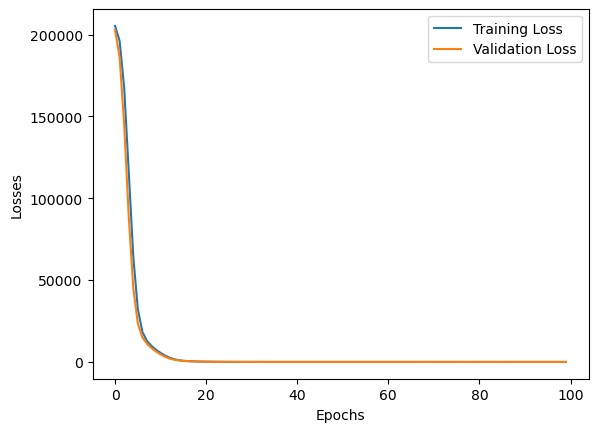

In [43]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [45]:
# loading the model 
model.load_state_dict(torch.load("best_model.pt1"))

<All keys matched successfully>

In [47]:
# Evaluation 
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())



Training MSE: 20.52292823791504
Testing MSE: 18.761964797973633


In [48]:
from sklearn.metrics import r2_score

print("R2 score:", r2_score(y_test, test_preds))

R2 score: 0.9344317687825111


In [50]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns = ["Predicted values"])
actual_df = pd.DataFrame(y_test.values, columns = ["Actual values"])

pd.concat([predicted_df, actual_df], axis = 1)

,Predicted values,Actual values
0,435.475037,433.27
1,436.759521,438.16
2,461.215271,458.42
3,475.955353,480.82
4,435.405212,441.41
...,...,...
1909,451.281708,456.70
1910,431.665558,438.04
1911,467.592468,467.80
1912,431.036133,437.14
